## LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Load semua file yang dibutuhkan
df_roberta = pd.read_csv("/content/sentiment_brand_agg (1).csv")
df_rulebased = pd.read_csv("/content/perbandingan_hasil_sentiment_analisis_table (1).csv")
df_ecommerce = pd.read_csv("/content/eda_ecommerce.csv")

print("RoBERTa:", df_roberta.shape)
print("Rule-Based:", df_rulebased.shape)
print("E-Commerce:", df_ecommerce.shape)

RoBERTa: (21, 9)
Rule-Based: (11, 7)
E-Commerce: (4433, 8)


In [3]:
df_roberta.head()

,Brand,Positif,Netral,Negatif,Total,Sentiment_Score_Avg,Weighted_Sentiment,Positif_Pct,Negatif_Pct
0,Vivo,36,102,17,155,0.1226,0.6191,23.2,11.0
1,Xiaomi,215,632,130,977,0.0870,0.5990,22.0,13.3
2,Sony,2,7,0,9,0.2222,0.5116,22.2,0.0
3,Infinix,96,313,63,472,0.0699,0.4305,20.3,13.3
4,Apple,40,74,28,142,0.0845,0.4194,28.2,19.7


In [4]:
df_rulebased.head()

,Brand,jumlah_komentar,sentiment_score_avg,rank_raw,weighted_sentiment,rank_weighted,rank_change
0,Xiaomi,976,0.088115,2,0.025504,1,1
1,Infinix,487,0.069815,3,0.010083,2,1
2,Vivo,182,0.159341,1,0.008600,3,-2
3,Samsung,460,0.043478,5,0.005931,4,1
4,iPhone,127,0.062992,4,0.002372,5,-1


In [5]:
df_ecommerce.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce,Brand_Ekstrak,Segmen_Harga,Valid_Terjual
0,devilmimi realme C71 8GB+16GB / 128GB Handphon...,2139000.0,568.0,surabaya (kota),Shopee,realme,Upper-Mid,True
1,Samsung Galaxy A07 4/64GB - Black,1599000.0,10000.0,surabaya (kota),Shopee,samsung,Mid-Range,True
2,Samsung Galaxy A16 8/128GB - Black,2759000.0,10000.0,jakarta utara (kota),Shopee,samsung,Upper-Mid,True
3,HP IPHONE 14 128GB - Garansi Resmi Indonesia,9165000.0,13.0,surabaya (kota),Shopee,apple,Premium,True
4,Infinix Hot 60i 6/128GB - Up to 12GB Extended ...,1799000.0,10000.0,jakarta utara (kota),Shopee,infinix,Mid-Range,True


## NORMALISASI NAMA BRAND

In [6]:
# Standarisasi nama brand ke huruf kapital di awal
brand_mapping_roberta = {
    'Vivo': 'Vivo',
    'Xiaomi': 'Xiaomi',
    'Sony': 'Sony',
    'Infinix': 'Infinix',
    'Apple': 'Apple',
    'Samsung': 'Samsung',
    'Nokia': 'Nokia',
    'Lenovo': 'Lenovo',
    'Meizu': 'Meizu',
    'Oneplus': 'OnePlus',
    'Motorola': 'Motorola',
    'Huawei': 'Huawei',
    'Nubia': 'Nubia',
    'Honor': 'Honor',
    'Oppo': 'Oppo',
    'Sharp': 'Sharp',
    'Iqoo': 'iQOO',
    'Google': 'Google',
    'Asus': 'Asus',
    'Realme': 'Realme',
    'Tecno': 'Tecno'
}

brand_mapping_rulebased = {
    'Xiaomi': 'Xiaomi',
    'Infinix': 'Infinix',
    'Vivo': 'Vivo',
    'Samsung': 'Samsung',
    'iPhone': 'Apple',      # samakan ke Apple
    'Motorola': 'Motorola',
    'Asus': 'Asus',
    'iQOO': 'iQOO',
    'Oppo': 'Oppo',
    'Realme': 'Realme',
    'Tecno': 'Tecno'
}

brand_mapping_ecommerce = {
    'samsung': 'Samsung',
    'realme': 'Realme',
    'apple': 'Apple',
    'infinix': 'Infinix',
    'xiaomi': 'Xiaomi',
    'redmi' : 'Xiaomi',
    'vivo': 'Vivo',
    'oppo': 'Oppo',
    'tecno': 'Tecno',
    'asus': 'Asus',
    'iqoo': 'iQOO',
    'motorola': 'Motorola',
    'poco': 'Poco',
    'itel': 'Itel',
    'nokia': 'Nokia',
    'lenovo': 'Lenovo',
    'honor': 'Honor',
    'huawei': 'Huawei',
    'google': 'Google',
    'sony': 'Sony',
}

**Interpretasi:** penggunaan dictionary manual dikarenakan nama brand pada dataset sebelumnya tidak diselaraskan semua, contohnya pada brand "IQOO" jika diubah lower menjadi "iqoo" tapi kalau diubah title menjadi "Iqoo". keduanya adalah penulisan yang resmi, namun lebih aman jika menggunakan mapping manual.

In [7]:
# Terapkan mapping ke masing-masing dataframe
df_roberta['Brand'] = df_roberta['Brand'].map(brand_mapping_roberta)
df_rulebased['Brand'] = df_rulebased['Brand'].map(brand_mapping_rulebased)
df_ecommerce['Brand'] = df_ecommerce['Brand_Ekstrak'].map(brand_mapping_ecommerce)

# Cek apakah ada brand yang tidak ter-mapping (hasilnya NaN)
print("RoBERTa tidak ter-mapping:", df_roberta['Brand'].isna().sum())
print("Rule-Based tidak ter-mapping:", df_rulebased['Brand'].isna().sum())
print("E-Commerce tidak ter-mapping:", df_ecommerce['Brand'].isna().sum())

RoBERTa tidak ter-mapping: 0
Rule-Based tidak ter-mapping: 0
E-Commerce tidak ter-mapping: 535


In [8]:
# Cek brand apa saja yang tidak ter-mapping di ecommerce
brand_tidak_mapped = df_ecommerce[df_ecommerce['Brand'].isna()]['Brand_Ekstrak'].value_counts()
print(brand_tidak_mapped)

Brand_Ekstrak
other             412
zte                86
advan              23
evercoss           13
non_smartphone      1
Name: count, dtype: int64


In [9]:
# Drop brand yang tidak ter-mapping
df_ecommerce = df_ecommerce.dropna(subset = ['Brand'])

print("E-Commerce setelah drop brand tidak relevan:", df_ecommerce.shape)
print("Brand yang tersisa:", sorted(df_ecommerce['Brand'].unique()))

E-Commerce setelah drop brand tidak relevan: (3898, 9)
Brand yang tersisa: ['Apple', 'Asus', 'Huawei', 'Infinix', 'Itel', 'Motorola', 'Nokia', 'Oppo', 'Poco', 'Realme', 'Samsung', 'Sony', 'Tecno', 'Vivo', 'Xiaomi', 'iQOO']


## PERBANDINGAN RULE-BASED VS ROBERTA

In [10]:
# Cek brand yang ada di kedua model
brand_roberta = set(df_roberta['Brand'].unique())
brand_rulebased = set(df_rulebased['Brand'].unique())
brand_ecommerce = set(df_ecommerce['Brand'].unique())

In [11]:
print("Brand RoBERTa:", sorted(brand_roberta))
print("\nBrand Rule-Based:", sorted(brand_rulebased))
print("\nBrand E-Commerce:", sorted(brand_ecommerce))

Brand RoBERTa: ['Apple', 'Asus', 'Google', 'Honor', 'Huawei', 'Infinix', 'Lenovo', 'Meizu', 'Motorola', 'Nokia', 'Nubia', 'OnePlus', 'Oppo', 'Realme', 'Samsung', 'Sharp', 'Sony', 'Tecno', 'Vivo', 'Xiaomi', 'iQOO']

Brand Rule-Based: ['Apple', 'Asus', 'Infinix', 'Motorola', 'Oppo', 'Realme', 'Samsung', 'Tecno', 'Vivo', 'Xiaomi', 'iQOO']

Brand E-Commerce: ['Apple', 'Asus', 'Huawei', 'Infinix', 'Itel', 'Motorola', 'Nokia', 'Oppo', 'Poco', 'Realme', 'Samsung', 'Sony', 'Tecno', 'Vivo', 'Xiaomi', 'iQOO']


In [12]:
print("Brand overlap RoBERTa & Rule-Based:", sorted(brand_roberta & brand_rulebased))
print("Brand hanya di RoBERTa:", sorted(brand_roberta - brand_rulebased))
print("Brand hanya di Rule-Based:", sorted(brand_rulebased - brand_roberta))

Brand overlap RoBERTa & Rule-Based: ['Apple', 'Asus', 'Infinix', 'Motorola', 'Oppo', 'Realme', 'Samsung', 'Tecno', 'Vivo', 'Xiaomi', 'iQOO']
Brand hanya di RoBERTa: ['Google', 'Honor', 'Huawei', 'Lenovo', 'Meizu', 'Nokia', 'Nubia', 'OnePlus', 'Sharp', 'Sony']
Brand hanya di Rule-Based: []


In [13]:
# Merge dua model berdasarkan brand yang overlap saja
df_compare = pd.merge(
    df_roberta[['Brand', 'Sentiment_Score_Avg', 'Weighted_Sentiment']],
    df_rulebased[['Brand', 'sentiment_score_avg', 'weighted_sentiment']],
    on      = 'Brand',
    how     = 'inner',       # hanya brand yang ada di keduanya
)

print("Jumlah brand yang bisa dibandingkan:", len(df_compare))
df_compare

Jumlah brand yang bisa dibandingkan: 11


,Brand,Sentiment_Score_Avg,Weighted_Sentiment,sentiment_score_avg,weighted_sentiment
0,Vivo,0.1226,0.6191,0.159341,0.008600
1,Xiaomi,0.0870,0.5990,0.088115,0.025504
2,Infinix,0.0699,0.4305,0.069815,0.010083
3,Apple,0.0845,0.4194,0.062992,0.002372
4,Samsung,0.0647,0.3905,0.043478,0.005931
5,Motorola,-0.0148,-0.0830,0.000000,0.000000
6,Oppo,-0.0556,-0.2890,-0.070423,-0.004448
7,iQOO,-0.0825,-0.3783,-0.089888,-0.002372
8,Asus,-0.1333,-0.5104,-0.102041,-0.001483
9,Realme,-0.1439,-0.7111,-0.153285,-0.006228


**Interpretasi:** menggunakan 'inner join' karena hanya mengambil brand yang ada dikedua dataframe tersebut.

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

df_compare['Weighted_Sentiment_roberta_norm'] = scaler.fit_transform(
    df_compare[['Weighted_Sentiment']]
)

df_compare['weighted_sentiment_rulebased_norm'] = scaler.fit_transform(
    df_compare[['weighted_sentiment']]
)

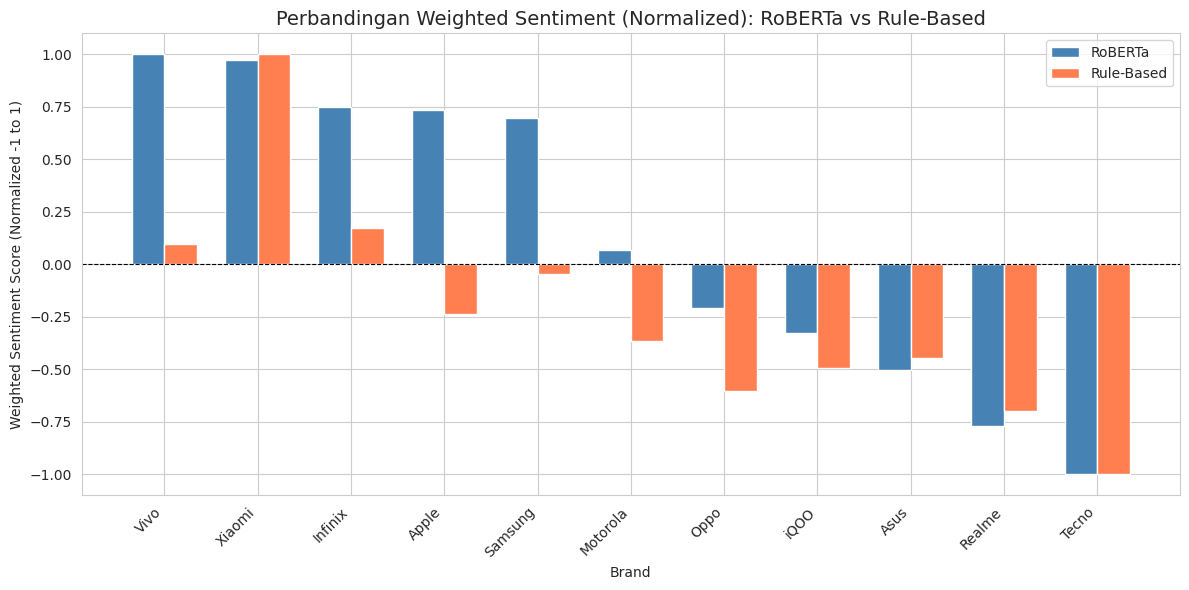

In [15]:
plt.figure(figsize = (12, 6))

x = np.arange(len(df_compare))
width = 0.35

plt.bar(x - width/2, df_compare['Weighted_Sentiment_roberta_norm'],
        width, label = 'RoBERTa', color = 'steelblue')
plt.bar(x + width/2, df_compare['weighted_sentiment_rulebased_norm'],
        width, label = 'Rule-Based', color = 'coral')

plt.axhline(0, color = 'black', linestyle = '--', linewidth = 0.8)
plt.xticks(x, df_compare['Brand'], rotation = 45, ha = 'right')
plt.title("Perbandingan Weighted Sentiment (Normalized): RoBERTa vs Rule-Based", fontsize = 14)
plt.xlabel("Brand")
plt.ylabel("Weighted Sentiment Score (Normalized -1 to 1)")
plt.legend()
plt.tight_layout()
plt.show()

## JUSTIFIKASI PEMILIHAN MODEL

In [16]:
# Tabel perbandingan performa kedua model
model_comparison = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Rule_Based': [0.6993, 0.7420, 0.6993, 0.6486],
    'RoBERTa': [0.8737, 0.8864, 0.8737, 0.8656]
})

model_comparison['Selisih'] = (
    model_comparison['RoBERTa'] - model_comparison['Rule_Based']
).round(4)

print(model_comparison.to_string(index=False))

   Metrik  Rule_Based  RoBERTa  Selisih
 Accuracy      0.6993   0.8737   0.1744
Precision      0.7420   0.8864   0.1444
   Recall      0.6993   0.8737   0.1744
 F1 Score      0.6486   0.8656   0.2170


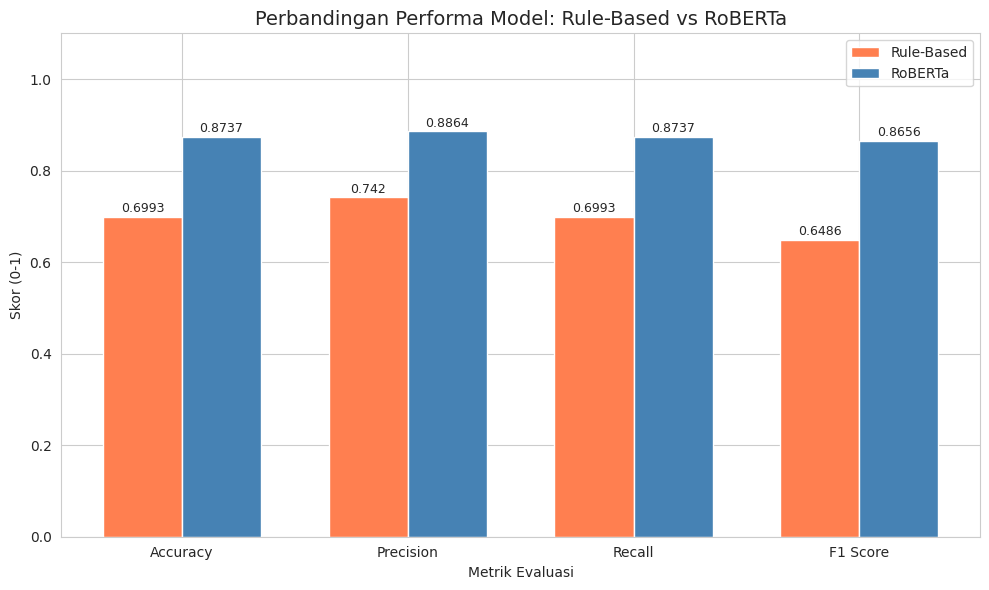

In [17]:
# Visualisasi perbandingan performa model
plt.figure(figsize=(10, 6))

x = np.arange(len(model_comparison['Metrik']))
width = 0.35

plt.bar(x - width/2, model_comparison['Rule_Based'],
        width, label='Rule-Based', color='coral')
plt.bar(x + width/2, model_comparison['RoBERTa'],
        width, label='RoBERTa', color='steelblue')

# Tambahkan angka di atas tiap bar
for i, (rb, ro) in enumerate(zip(model_comparison['Rule_Based'], model_comparison['RoBERTa'])):
    plt.text(i - width/2, rb + 0.01, str(rb), ha='center', fontsize=9)
    plt.text(i + width/2, ro + 0.01, str(ro), ha='center', fontsize=9)

plt.ylim(0, 1.1)
plt.xticks(x, model_comparison['Metrik'])
plt.title("Perbandingan Performa Model: Rule-Based vs RoBERTa", fontsize=14)
plt.xlabel("Metrik Evaluasi")
plt.ylabel("Skor (0-1)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Kesimpulan pemilihan model
print("KESIMPULAN PEMILIHAN MODEL")
print(f"""
Model terpilih : RoBERTa
Alasan         :
  - Accuracy  lebih tinggi: 0.8737 vs 0.6993 (+17.44%)
  - Precision lebih tinggi: 0.8864 vs 0.7420 (+14.44%)
  - Recall    lebih tinggi: 0.8737 vs 0.6993 (+17.44%)
  - F1 Score  lebih tinggi: 0.8656 vs 0.6486 (+21.70%)

RoBERTa adalah model deep learning berbasis transformer
yang dilatih khusus untuk memahami konteks kalimat,
sehingga lebih akurat mengenali sentimen pada komentar
informal berbahasa Indonesia dibanding Rule-Based yang
hanya mengandalkan pencocokan kata kunci.

Selanjutnya analisis menggunakan hasil sentimen RoBERTa
dari file sentiment_brand_agg.csv
""")

KESIMPULAN PEMILIHAN MODEL

Model terpilih : RoBERTa
Alasan         :
  - Accuracy  lebih tinggi: 0.8737 vs 0.6993 (+17.44%)
  - Precision lebih tinggi: 0.8864 vs 0.7420 (+14.44%)
  - Recall    lebih tinggi: 0.8737 vs 0.6993 (+17.44%)
  - F1 Score  lebih tinggi: 0.8656 vs 0.6486 (+21.70%)

RoBERTa adalah model deep learning berbasis transformer
yang dilatih khusus untuk memahami konteks kalimat,
sehingga lebih akurat mengenali sentimen pada komentar
informal berbahasa Indonesia dibanding Rule-Based yang
hanya mengandalkan pencocokan kata kunci.

Selanjutnya analisis menggunakan hasil sentimen RoBERTa
dari file sentiment_brand_agg.csv



## AGREGASI E-COMMERCE PER BRAND

In [19]:
# Groupby brand untuk hitung total terjual dan rata-rata harga
df_ecom_agg = df_ecommerce.groupby('Brand').agg(
    total_listing  = ('Produk', 'count'),
    total_terjual  = ('Produk_Terjual', 'sum'),
    avg_harga      = ('Harga_Produk', 'mean')
).reset_index()

df_ecom_agg['avg_harga'] = df_ecom_agg['avg_harga'].round(2)
df_ecom_agg['total_terjual'] = df_ecom_agg['total_terjual'].round(0).astype(int)

print("Jumlah brand e-commerce:", len(df_ecom_agg))
df_ecom_agg.sort_values('total_terjual', ascending=False)

Jumlah brand e-commerce: 16


,Brand,total_listing,total_terjual,avg_harga
3,Infinix,582,618540,1918193.52
10,Samsung,818,428385,4412702.02
13,Vivo,347,385559,2983920.42
14,Xiaomi,581,144710,3136497.28
0,Apple,154,97177,8205674.99
7,Oppo,375,71376,3487174.25
6,Nokia,65,56666,436719.69
9,Realme,297,42424,2525421.52
8,Poco,121,38505,3645837.81
4,Itel,101,33636,1400271.16


## MERGE SENTIMENT + E-COMMERCE

In [20]:
# Gunakan df_roberta karena sudah terpilih sebagai model terbaik
df_final = pd.merge(
    df_roberta[['Brand', 'Sentiment_Score_Avg', 'Weighted_Sentiment',
                'Positif_Pct', 'Negatif_Pct', 'Total']],
    df_ecom_agg,
    on='Brand',
    how='inner'
)

print("Jumlah brand final:", len(df_final))
print("Kolom:", df_final.columns.tolist())
df_final

Jumlah brand final: 14
Kolom: ['Brand', 'Sentiment_Score_Avg', 'Weighted_Sentiment', 'Positif_Pct', 'Negatif_Pct', 'Total', 'total_listing', 'total_terjual', 'avg_harga']


,Brand,Sentiment_Score_Avg,Weighted_Sentiment,Positif_Pct,Negatif_Pct,Total,total_listing,total_terjual,avg_harga
0,Vivo,0.1226,0.6191,23.2,11.0,155,347,385559,2983920.42
1,Xiaomi,0.0870,0.5990,22.0,13.3,977,581,144710,3136497.28
2,Sony,0.2222,0.5116,22.2,0.0,9,5,52,10495600.00
3,Infinix,0.0699,0.4305,20.3,13.3,472,582,618540,1918193.52
4,Apple,0.0845,0.4194,28.2,19.7,142,154,97177,8205674.99
5,Samsung,0.0647,0.3905,18.7,12.2,417,818,428385,4412702.02
6,Nokia,0.2000,0.3584,40.0,20.0,5,65,56666,436719.69
7,Motorola,-0.0148,-0.0830,15.1,16.6,271,36,1610,3616361.11
8,Huawei,-0.0556,-0.1637,11.1,16.7,18,8,630,6896000.00
9,Oppo,-0.0556,-0.2890,16.1,21.7,180,375,71376,3487174.25


## COMPOSITE SCORE

In [21]:
# Normalisasi 3 faktor ke skala 0-1 menggunakan Min-Max
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_final['norm_sentiment'] = scaler.fit_transform(
    df_final[['Weighted_Sentiment']]
)
df_final['norm_terjual'] = scaler.fit_transform(
    df_final[['total_terjual']]
)
df_final['norm_harga'] = scaler.fit_transform(
    df_final[['avg_harga']]
)

print("Cek hasil normalisasi (min=0, max=1):")
print(df_final[['Brand','norm_sentiment','norm_terjual','norm_harga']].round(4))

Cek hasil normalisasi (min=0, max=1):
       Brand  norm_sentiment  norm_terjual  norm_harga
0       Vivo          1.0000        0.6233      0.2532
1     Xiaomi          0.9866        0.2339      0.2684
2       Sony          0.9285        0.0000      1.0000
3    Infinix          0.8746        1.0000      0.1473
4      Apple          0.8672        0.1570      0.7723
5    Samsung          0.8480        0.6925      0.3953
6      Nokia          0.8266        0.0915      0.0000
7   Motorola          0.5331        0.0025      0.3161
8     Huawei          0.4794        0.0009      0.6421
9       Oppo          0.3960        0.1153      0.3033
10      iQOO          0.3367        0.0033      0.3715
11      Asus          0.2488        0.0000      0.6072
12    Realme          0.1153        0.0685      0.2076
13     Tecno          0.0000        0.0367      0.2034


In [22]:
# Hitung composite score dengan bobot
# Sentiment 40%, Penjualan 35%, Harga 25%
# Catatan: harga di-inverse karena harga rendah bukan berarti brand buruk
# konteksnya: harga lebih mencerminkan segmen, bukan kualitas
# jadi kita tidak masukkan harga sebagai faktor "semakin tinggi semakin baik"
# melainkan kita gunakan sebagai faktor konteks saja dengan bobot kecil

BOBOT_SENTIMENT = 0.40
BOBOT_TERJUAL   = 0.35
BOBOT_HARGA     = 0.25

df_final['composite_score'] = (
    (df_final['norm_sentiment'] * BOBOT_SENTIMENT) +
    (df_final['norm_terjual']   * BOBOT_TERJUAL)   +
    (df_final['norm_harga']     * BOBOT_HARGA)
).round(4)

df_final = df_final.sort_values('composite_score', ascending=False).reset_index(drop=True)
df_final['rank_composite'] = df_final.index + 1

print(df_final[['rank_composite', 'Brand', 'composite_score',
                'norm_sentiment', 'norm_terjual', 'norm_harga']])

    rank_composite     Brand  composite_score  norm_sentiment  norm_terjual  \
0                1   Infinix           0.7366        0.874568      1.000000   
1                2      Vivo           0.6815        1.000000      0.623306   
2                3   Samsung           0.6804        0.847965      0.692549   
3                4      Sony           0.6214        0.928505      0.000000   
4                5     Apple           0.5949        0.867185      0.157036   
5                6    Xiaomi           0.5436        0.986632      0.233890   
6                7     Nokia           0.3627        0.826616      0.091536   
7                8    Huawei           0.3526        0.479383      0.000935   
8                9  Motorola           0.2931        0.533054      0.002519   
9               10      Oppo           0.2746        0.396049      0.115320   
10              11      Asus           0.2513        0.248803      0.000034   
11              12      iQOO           0.2287       

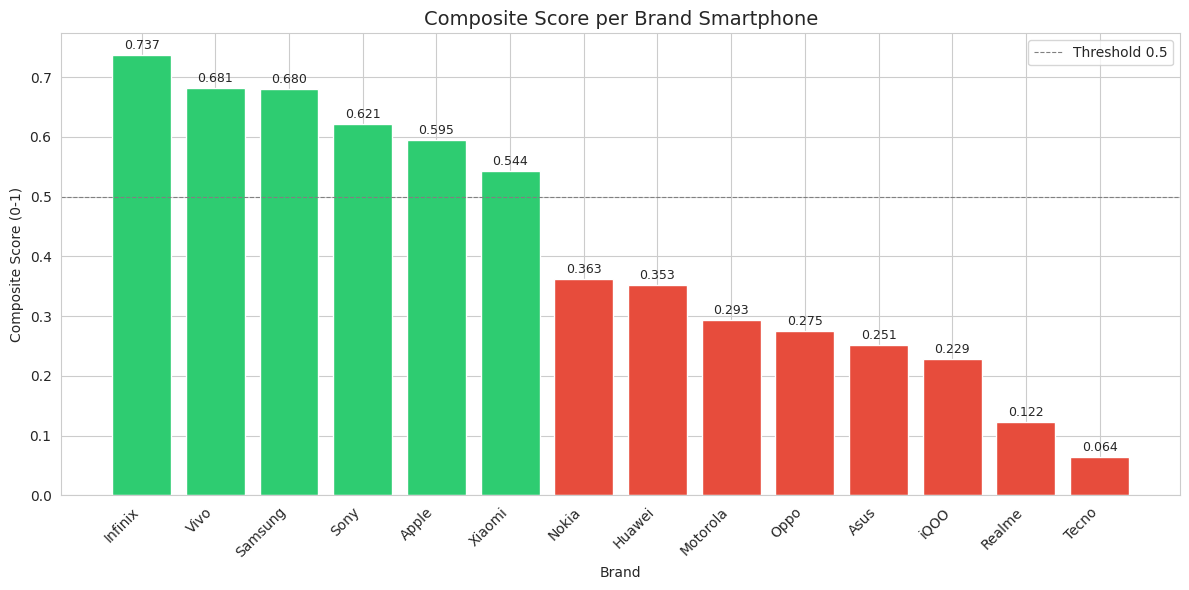

In [23]:
# Visualisasi composite score
plt.figure(figsize=(12, 6))

colors = ['#2ecc71' if s >= 0.5 else '#e74c3c'
          for s in df_final['composite_score']]

bars = plt.bar(df_final['Brand'], df_final['composite_score'], color=colors)

# Label angka di atas bar
for bar, score in zip(bars, df_final['composite_score']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.3f}',
             ha='center', fontsize=9)

plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Threshold 0.5')
plt.title("Composite Score per Brand Smartphone", fontsize=14)
plt.xlabel("Brand")
plt.ylabel("Composite Score (0-1)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretasi:**

Brand di atas threshold 0.5 (performa baik):
* Infinix (0.737) → juara karena penjualan tertinggi (618.540 unit) + sentimen
positif
* Vivo (0.681) → sentimen terbaik di antara semua brand tapi penjualan nomor 3
* Samsung (0.680) → listing terbanyak (818) + penjualan tinggi (428.385 unit)
* Sony (0.621) → menarik! masuk top 4 padahal penjualan sangat rendah (52 unit) — ini karena harga Sony tertinggi (Rp 10,4 juta) mendongkrak norm_harga-nya ke 1.0
* Apple (0.595) → premium, penjualan sedang tapi harga tinggi membantu skornya
* Xiaomi (0.544) → sentimen bagus tapi penjualan mengecewakan relatif terhadap brand size-nya

**Catatan penting soal Sony:** Sony masuk top 4 bukan karena performa pasar yang sesungguhnya, melainkan karena faktor harga yang sangat tinggi. Hanya 9 komentar YouTube dan 52 unit terjual, datanya terlalu kecil untuk representatif. Hal ini menjadi keterbatasan analisis yang perlu disebutkan di laporan.

## KORELASI

In [24]:
# Korelasi 1: Weighted Sentiment vs Total Terjual
r1, p1 = stats.pearsonr(df_final['Weighted_Sentiment'], df_final['total_terjual'])

print("KORELASI 1: Weighted Sentiment vs Total Terjual\n")
print(f"Pearson r : {r1:.4f}")
print(f"P-value   : {p1:.4f}")

if abs(r1) < 0.3:
    kekuatan = "lemah"
elif abs(r1) < 0.6:
    kekuatan = "sedang"
else:
    kekuatan = "kuat"

arah = "positif" if r1 > 0 else "negatif"
signifikan = "signifikan" if p1 < 0.05 else "tidak signifikan"

print(f"\nHasil Korelasi: Korelasi {arah} {kekuatan} ({signifikan})")
print(f"Artinya: Brand dengan sentimen lebih tinggi")
print(f"{'\nBuktinya: CENDERUNG' if p1 < 0.05 else 'BELUM TERBUKTI'} memiliki penjualan lebih tinggi")

KORELASI 1: Weighted Sentiment vs Total Terjual

Pearson r : 0.5354
P-value   : 0.0485

Hasil Korelasi: Korelasi positif sedang (signifikan)
Artinya: Brand dengan sentimen lebih tinggi

Buktinya: CENDERUNG memiliki penjualan lebih tinggi


**Interpretasi:** sentimen publik di YouTube ada hubungannya dengan penjualan di marketplace, tapi tidak kuat. Konsumen yang memberikan komentar positif tentang suatu brand cenderung juga membelinya, tapi faktor lain seperti harga, promosi, dan distribusi juga berperan besar.

**Dapat dilihat dari scatter plot:** Infinix, VivoSamsung berada di kuadran kanan atas (sentimen tinggi + penjualan tinggi). Sebaliknya Tecno dan Realme di kiri bawah (sentimen rendah + penjualan rendah). Pola ini konsisten dengan korelasi positif.

In [25]:
# Korelasi 2: Avg Harga vs Total Terjual
r2, p2 = stats.pearsonr(df_final['avg_harga'], df_final['total_terjual'])

print("KORELASI 2: Avg Harga vs Total Terjual\n")
print(f"Pearson r : {r2:.4f}")
print(f"P-value   : {p2:.4f}")

if abs(r2) < 0.3:
    kekuatan2 = "lemah"
elif abs(r2) < 0.6:
    kekuatan2 = "sedang"
else:
    kekuatan2 = "kuat"

arah2 = "positif" if r2 > 0 else "negatif"
signifikan2 = "signifikan" if p2 < 0.05 else "tidak signifikan"

print(f"\nHasil Korelasi: Korelasi {arah2} {kekuatan2} ({signifikan2})")
print(f"Artinya: Brand dengan harga lebih tinggi")
print(f"{'\nBuktinya: CENDERUNG' if p2 < 0.05 else '\nBuktinya: BELUM TERBUKTI'} memiliki penjualan lebih tinggi/rendah")

KORELASI 2: Avg Harga vs Total Terjual

Pearson r : -0.3239
P-value   : 0.2586

Hasil Korelasi: Korelasi negatif sedang (tidak signifikan)
Artinya: Brand dengan harga lebih tinggi

Buktinya: BELUM TERBUKTI memiliki penjualan lebih tinggi/rendah


**Interpretasi:** meskipun ada kecenderungan brand dengan harga lebih tinggi terjual lebih sedikit, hubungan ini tidak bisa dibuktikan secara statistik dengan data ini (p > 0.05). Jadi kita tidak bisa menyimpulkan "mahal = susah laku" dari data ini saja.

Hal ini masuk akal karena Apple harganya tinggi tapi penjualannya lumayan, sementara Nokia harganya sangat murah tapi penjualannya juga tidak luar biasa.

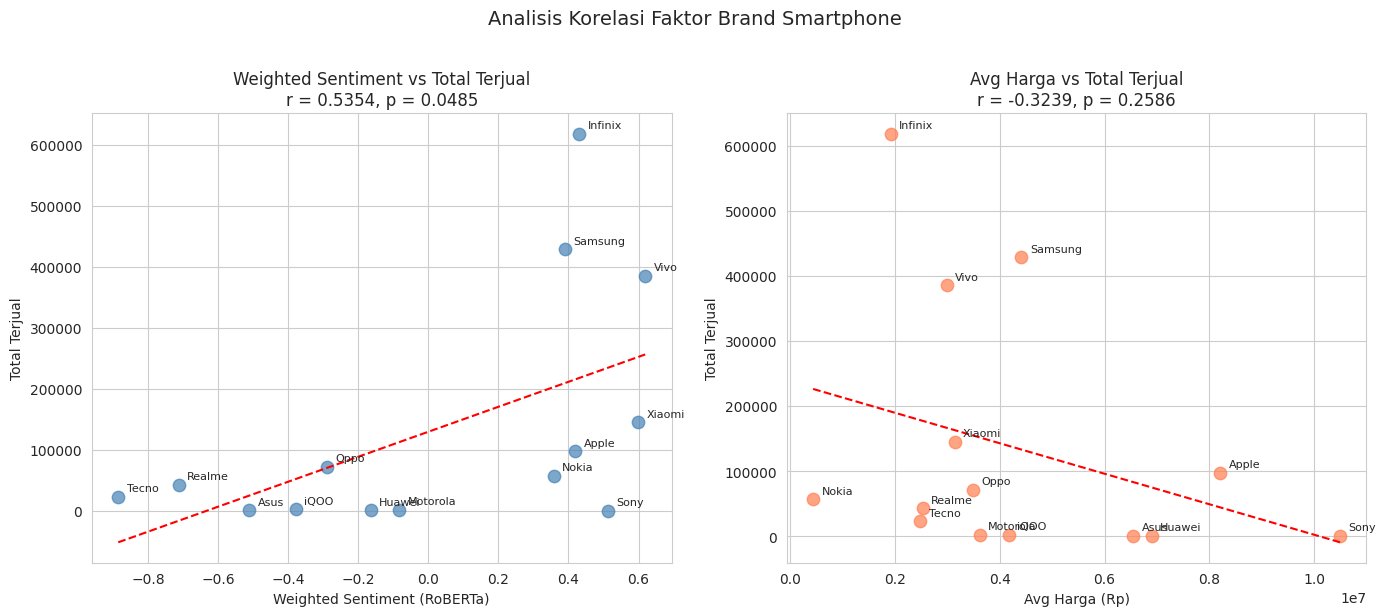

In [26]:
# Scatter plot korelasi 1
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Sentiment vs Terjual
axes[0].scatter(df_final['Weighted_Sentiment'],
                df_final['total_terjual'],
                color='steelblue', s=80, alpha=0.7)

for _, row in df_final.iterrows():
    axes[0].annotate(row['Brand'],
                     (row['Weighted_Sentiment'], row['total_terjual']),
                     textcoords="offset points",
                     xytext=(6, 4), fontsize=8)

# Garis tren
z1 = np.polyfit(df_final['Weighted_Sentiment'], df_final['total_terjual'], 1)
p_line1 = np.poly1d(z1)
x_line1 = np.linspace(df_final['Weighted_Sentiment'].min(),
                       df_final['Weighted_Sentiment'].max(), 100)
axes[0].plot(x_line1, p_line1(x_line1), 'r--', linewidth=1.5)

axes[0].set_title(f"Weighted Sentiment vs Total Terjual\nr = {r1:.4f}, p = {p1:.4f}", fontsize=12)
axes[0].set_xlabel("Weighted Sentiment (RoBERTa)")
axes[0].set_ylabel("Total Terjual")

# Plot 2: Harga vs Terjual
axes[1].scatter(df_final['avg_harga'],
                df_final['total_terjual'],
                color='coral', s=80, alpha=0.7)

for _, row in df_final.iterrows():
    axes[1].annotate(row['Brand'],
                     (row['avg_harga'], row['total_terjual']),
                     textcoords="offset points",
                     xytext=(6, 4), fontsize=8)

z2 = np.polyfit(df_final['avg_harga'], df_final['total_terjual'], 1)
p_line2 = np.poly1d(z2)
x_line2 = np.linspace(df_final['avg_harga'].min(),
                       df_final['avg_harga'].max(), 100)
axes[1].plot(x_line2, p_line2(x_line2), 'r--', linewidth=1.5)

axes[1].set_title(f"Avg Harga vs Total Terjual\nr = {r2:.4f}, p = {p2:.4f}", fontsize=12)
axes[1].set_xlabel("Avg Harga (Rp)")
axes[1].set_ylabel("Total Terjual")

plt.suptitle("Analisis Korelasi Faktor Brand Smartphone", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi Grafik Kiri — Weighted Sentiment vs Total Terjual**

r = 0.5354, p = 0.0485

**Pola yang terlihat dari scatter plot:**
Kuadran kanan atas (sentimen tinggi + terjual tinggi) → Brand sehat:
* Infinix → outlier positif terbesar, sentimen ~0.43 tapi terjual 618.540 unit
* Vivo → sentimen tertinggi (0.62) dengan penjualan 385.559 unit
* Samsung → sentimen positif + penjualan tinggi, konsisten

**Kuadran kiri bawah (sentimen rendah + terjual rendah) → Brand bermasalah:**
* Tecno dan Realme → sentimen negatif dan penjualan rendah, konsisten satu sama lain
* Asus → sentimen sangat negatif (-0.51) tapi penjualan hampir nol

**Yang anomali:**
* Xiaomi → sentimen tinggi (0.60) tapi penjualan hanya 144.710, jauh di bawah garis tren → artinya Xiaomi underperform di penjualan relatif terhadap sentimennya yang bagus
* Sony → sentimen positif tapi penjualan mendekati nol → tidak representatif, hanya 9 komentar

**Kesimpulan grafik kiri:** Garis tren merah menanjak ke kanan membuktikan korelasi positif. Brand dengan sentimen lebih baik di YouTube cenderung terjual lebih banyak, tetapi Infinix adalah pengecualian menarik karena penjualannya jauh di atas garis tren, artinya ada faktor lain yang sangat mendorong penjualan Infinix selain sentimen.

**Interpretasi Grafik Kanan — Avg Harga vs Total Terjual**

r = -0.3239, p = 0.2586

**Pola yang terlihat:**
Harga rendah + terjual tinggi:
* Infinix (Rp 1,9 juta) → terjual 618.540 unit → raja pasar budget
* Vivo (Rp 2,9 juta) → terjual 385.559 unit
* Samsung (Rp 4,4 juta) → terjual 428.385 unit → anomali! harga mid-high tapi terjual banyak, ini karena Samsung punya lineup sangat luas dari entry sampai premium

Harga tinggi + terjual rendah:
* Sony (Rp 10,4 juta) → hanya 52 unit
* Huawei (Rp 6,9 juta) → hanya 630 unit
* Asus (Rp 6,5 juta) → hanya 73 unit

**Kesimpulan grafik kanan:** Garis tren menurun ke kanan menunjukkan kecenderungan negatif, brand mahal cenderung terjual lebih sedikit. Tapi p = 0.2586 > 0.05, jadi hubungan ini tidak terbukti signifikan secara statistik. Artinya harga bukan penentu utama penjualan, brand equity, distribusi, dan promosi marketplace lebih berpengaruh.

## PENYIMPANAN OUTPUT

In [27]:
# Simpan final_brand_comparison.csv
df_final.to_csv("final_brand_comparison_tanpa_kuadran.csv", index=False)
print("Tersimpan: final_brand_comparison_tanpa_kuadran.csv")
print("Kolom:", df_final.columns.tolist())
print("Shape:", df_final.shape)

Tersimpan: final_brand_comparison_tanpa_kuadran.csv
Kolom: ['Brand', 'Sentiment_Score_Avg', 'Weighted_Sentiment', 'Positif_Pct', 'Negatif_Pct', 'Total', 'total_listing', 'total_terjual', 'avg_harga', 'norm_sentiment', 'norm_terjual', 'norm_harga', 'composite_score', 'rank_composite']
Shape: (14, 14)


In [28]:
df_final

,Brand,Sentiment_Score_Avg,Weighted_Sentiment,Positif_Pct,Negatif_Pct,Total,total_listing,total_terjual,avg_harga,norm_sentiment,norm_terjual,norm_harga,composite_score,rank_composite
0,Infinix,0.0699,0.4305,20.3,13.3,472,582,618540,1918193.52,0.874568,1.000000,0.147280,0.7366,1
1,Vivo,0.1226,0.6191,23.2,11.0,155,347,385559,2983920.42,1.000000,0.623306,0.253229,0.6815,2
2,Samsung,0.0647,0.3905,18.7,12.2,417,818,428385,4412702.02,0.847965,0.692549,0.395271,0.6804,3
3,Sony,0.2222,0.5116,22.2,0.0,9,5,52,10495600.00,0.928505,0.000000,1.000000,0.6214,4
4,Apple,0.0845,0.4194,28.2,19.7,142,154,97177,8205674.99,0.867185,0.157036,0.772348,0.5949,5
5,Xiaomi,0.0870,0.5990,22.0,13.3,977,581,144710,3136497.28,0.986632,0.233890,0.268397,0.5436,6
6,Nokia,0.2000,0.3584,40.0,20.0,5,65,56666,436719.69,0.826616,0.091536,0.000000,0.3627,7
7,Huawei,-0.0556,-0.1637,11.1,16.7,18,8,630,6896000.00,0.479383,0.000935,0.642147,0.3526,8
8,Motorola,-0.0148,-0.0830,15.1,16.6,271,36,1610,3616361.11,0.533054,0.002519,0.316103,0.2931,9
9,Oppo,-0.0556,-0.2890,16.1,21.7,180,375,71376,3487174.25,0.396049,0.115320,0.303260,0.2746,10
